In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [4]:
Data = pd.read_csv('/kaggle/input/dataset/Data.csv')
Data['timestamp'] = pd.to_datetime(Data['timestamp'], format="%d/%m/%Y %H:%M")
Data = Data.sort_values('timestamp') # SORTING THE VALUES IN ASCENDING ORDER
data = Data.iloc[4:,:]
Data.reset_index(inplace = True, drop = True)

Data

,Unnamed: 0,timestamp,current,voltage,soc
0,71954.0,2021-11-09 07:05:00,0.0,52.3,59.0
1,71955.0,2021-11-09 07:05:00,0.0,57.3,93.0
2,71956.0,2021-11-09 07:07:00,12.8,56.7,93.0
3,71957.0,2021-11-09 07:07:00,2.9,57.1,93.0
4,71958.0,2021-11-09 07:07:00,0.0,57.1,93.0
...,...,...,...,...,...
81135,11960.0,2022-01-31 17:10:00,0.0,54.2,72.0
81136,11959.0,2022-01-31 17:10:00,0.0,54.2,72.0
81137,11961.0,2022-01-31 17:12:00,0.0,54.2,72.0
81138,NaN,NaT,NaN,NaN,NaN


In [5]:
print("Data ")
print(Data.isna().sum())
print("\n")



Data 
Unnamed: 0    2
timestamp     2
current       2
voltage       2
soc           2
dtype: int64




In [6]:

# Remove rows with any missing values
Data = Data.dropna()
print("Data after removing missing rows:")
print(Data.isna().sum())


Data after removing missing rows:
Unnamed: 0    0
timestamp     0
current       0
voltage       0
soc           0
dtype: int64


In [7]:
x = Data.iloc[:, 1:4].values
y = Data.iloc[:, 3].values

In [8]:
x

array([[Timestamp('2021-11-09 07:05:00'), 0.0, 52.3],
       [Timestamp('2021-11-09 07:05:00'), 0.0, 57.3],
       [Timestamp('2021-11-09 07:07:00'), 12.8, 56.7],
       ...,
       [Timestamp('2022-01-31 17:10:00'), 0.0, 54.2],
       [Timestamp('2022-01-31 17:10:00'), 0.0, 54.2],
       [Timestamp('2022-01-31 17:12:00'), 0.0, 54.2]], dtype=object)

In [9]:

y

array([52.3, 57.3, 56.7, ..., 54.2, 54.2, 54.2])

In [10]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81138 entries, 0 to 81137
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  81138 non-null  float64       
 1   timestamp   81138 non-null  datetime64[ns]
 2   current     81138 non-null  float64       
 3   voltage     81138 non-null  float64       
 4   soc         81138 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 3.7 MB


Variation with respect to time


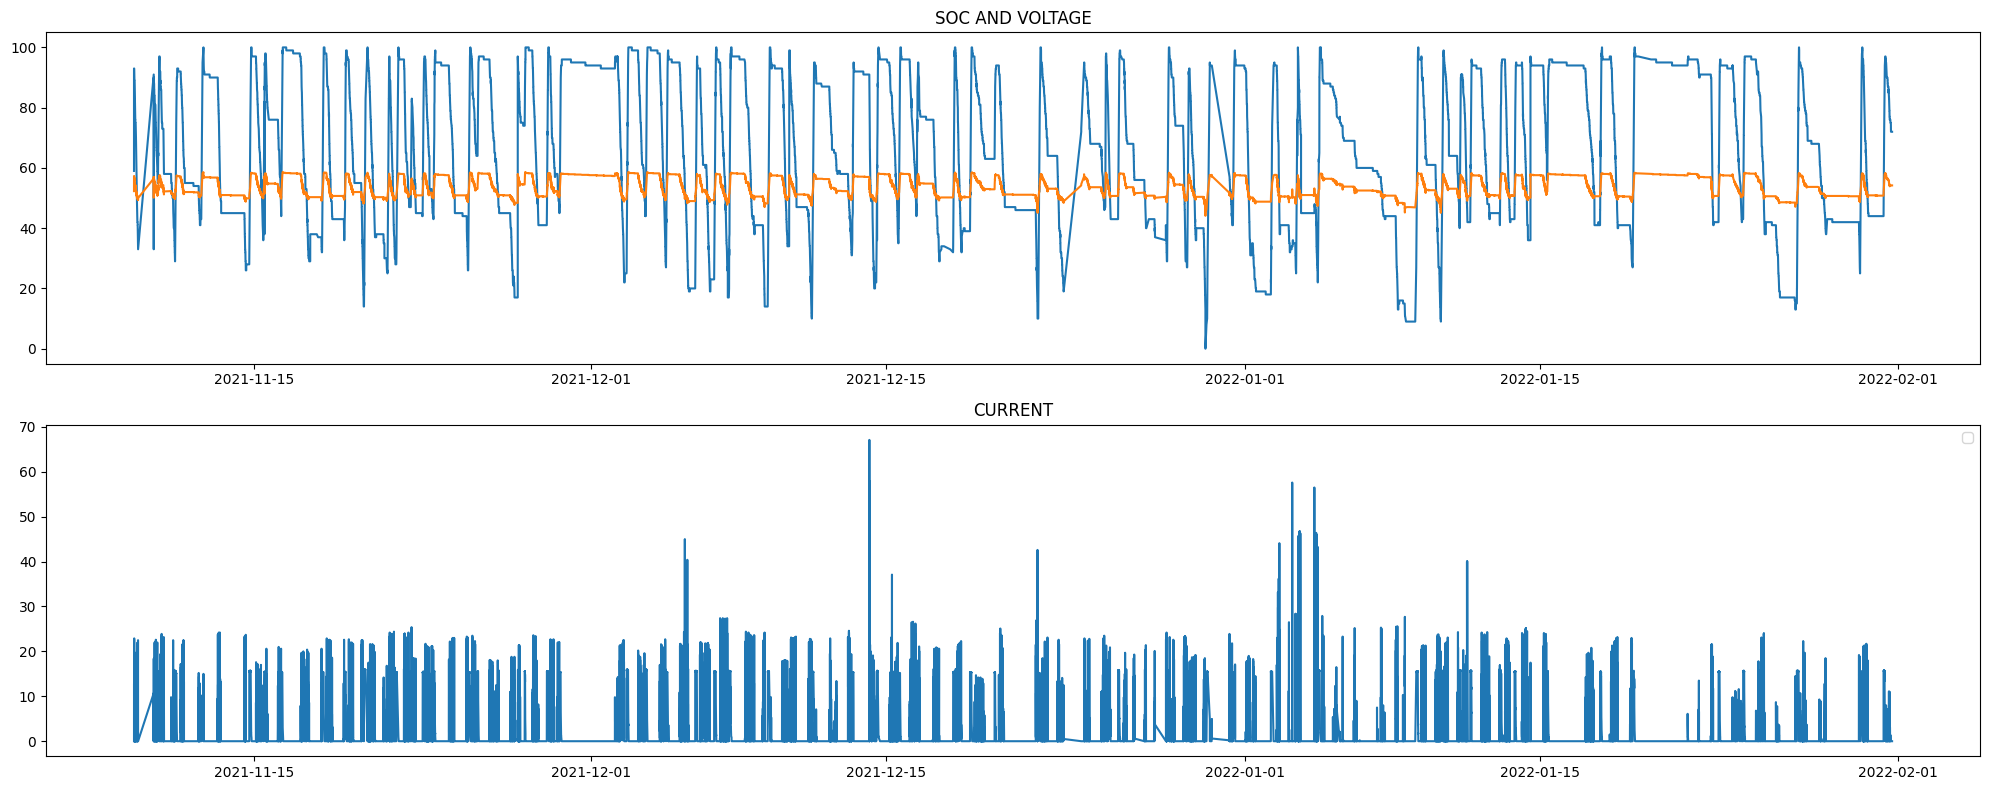

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))  # 1x3 grid

axes[0].plot(Data["timestamp"], Data["soc"], label = "SOC")
axes[0].plot(Data["timestamp"], Data["voltage"], label = "VOLTAGE")
axes[0].set_title('SOC AND VOLTAGE')
plt.legend()

axes[1].plot(Data["timestamp"], Data["current"])
axes[1].set_title('CURRENT')

plt.tight_layout()
plt.show();

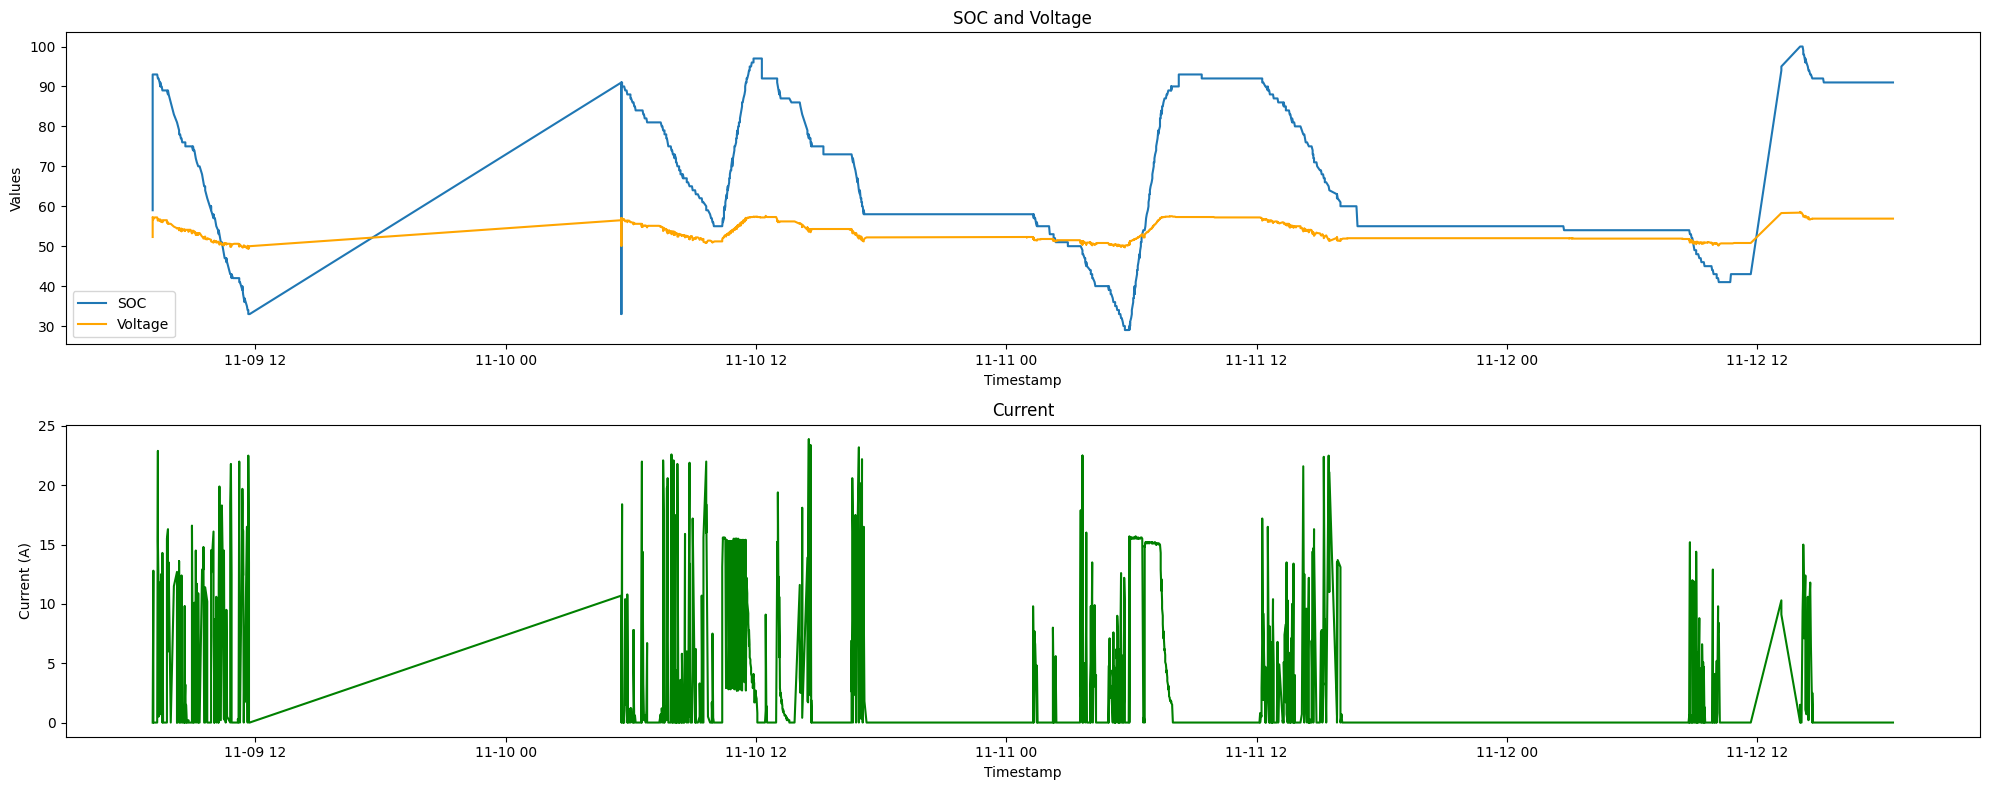

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(20, 8))  # 2x1 grid

# Plot SOC and Voltage on the first subplot
axes[0].plot(Data["timestamp"][:3000], Data["soc"][:3000], label="SOC")
axes[0].plot(Data["timestamp"][:3000], Data["voltage"][:3000], label="Voltage", color="orange")
axes[0].set_title('SOC and Voltage')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Values')
axes[0].legend()

# Plot Current on the second subplot
axes[1].plot(Data["timestamp"][:3000], Data["current"][:3000], color="green")
axes[1].set_title('Current')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Current (A)')

# Adjust layout
plt.tight_layout()
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


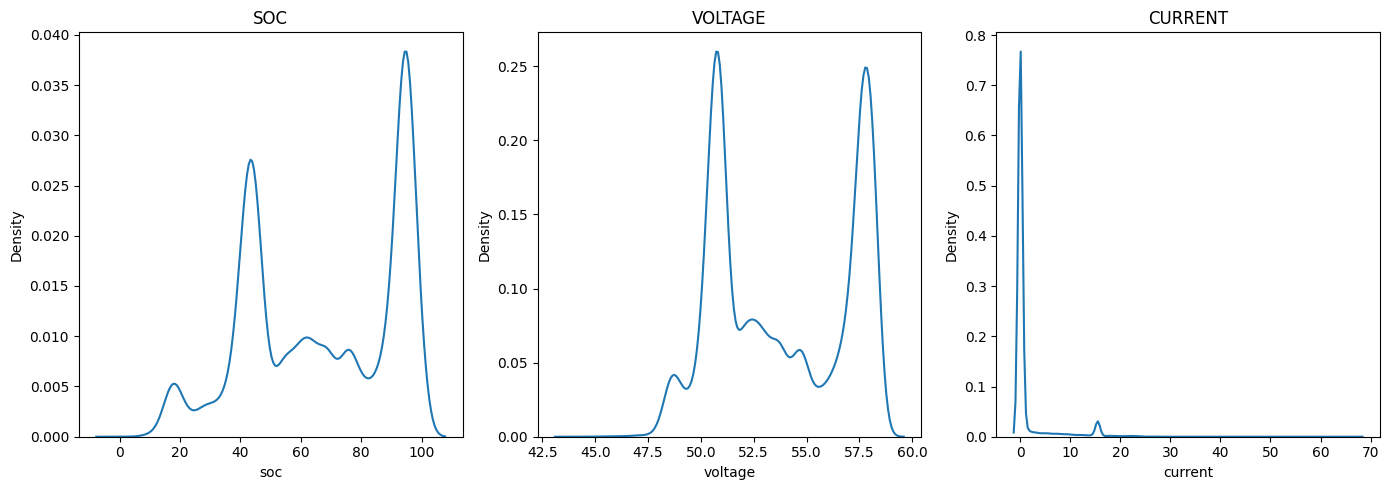

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))  # 1x3 grid

sns.kdeplot(data=Data["soc"], ax=axes[0])
axes[0].set_title('SOC')

sns.kdeplot(data=Data["voltage"], ax=axes[1])
axes[1].set_title('VOLTAGE')

sns.kdeplot(data=Data["current"], ax=axes[2])
axes[2].set_title('CURRENT')

plt.tight_layout()
plt.show();

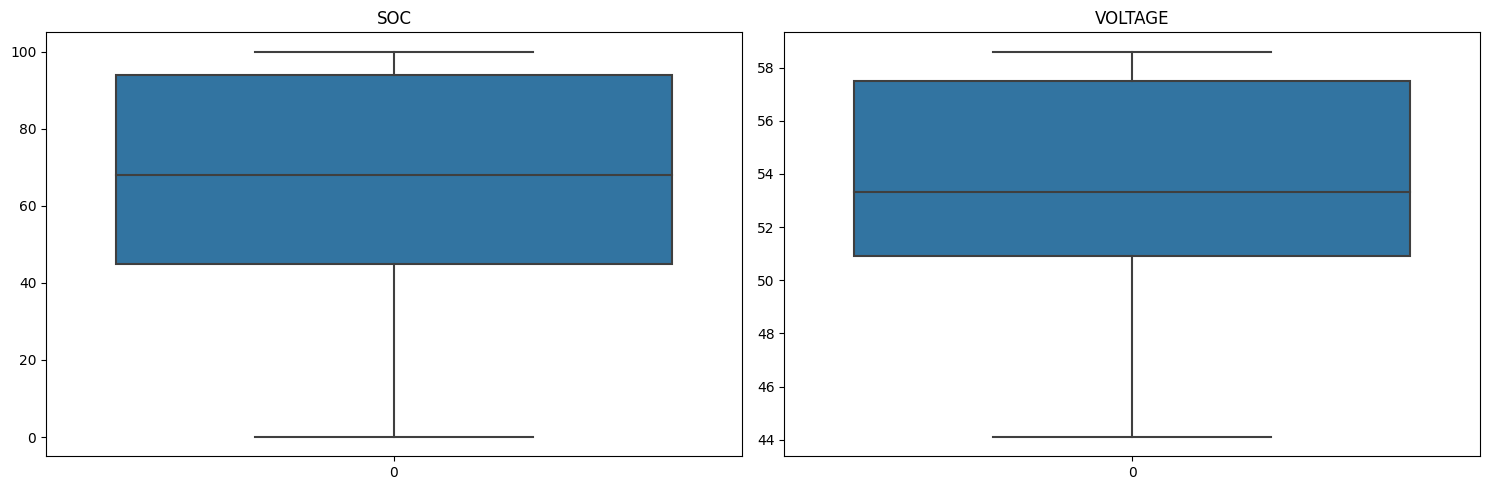

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # 1x3 grid

# Plot boxplots for each dataset in each subplot
sns.boxplot(data=Data["soc"], ax=axes[0])
axes[0].set_title('SOC')

sns.boxplot(data=Data["voltage"], ax=axes[1])
axes[1].set_title('VOLTAGE')

plt.tight_layout()
plt.show();

# NO OUTLIERS

In [16]:

x = Data.iloc[:, 1:4].values
y = Data.iloc[:, 3].values

In [19]:
Data.describe()

,Unnamed: 0,timestamp,current,voltage,soc
count,81138.000000,81138,81138.000000,81138.000000,81138.000000
mean,40570.149277,2021-12-21 08:39:10.918435072,1.347678,53.854491,67.111440
min,0.000000,2021-11-09 07:05:00,0.000000,44.100000,0.000000
25%,20285.250000,2021-11-29 07:12:00,0.000000,50.900000,45.000000
50%,40570.500000,2021-12-19 22:08:00,0.000000,53.300000,68.000000
75%,60854.750000,2022-01-12 19:07:00,0.000000,57.500000,94.000000
max,81139.000000,2022-01-31 17:12:00,67.100000,58.600000,100.000000
std,23423.097900,NaN,4.148856,3.204733,24.870448


Data modeling


In [20]:
from sklearn.preprocessing import MinMaxScaler

# Convert timestamp to numeric format (e.g., Unix timestamp)
Data['timestamp'] = pd.to_datetime(Data['timestamp'])
Data['timestamp'] = Data['timestamp'].astype('int64') / 1e9  # Convert to seconds

# Apply MinMaxScaler to numerical columns
sc = MinMaxScaler()
numericals = ['timestamp', 'voltage', 'current', 'soc']
Data[numericals] = sc.fit_transform(Data[numericals])


/tmp/ipykernel_30/3639809895.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data['timestamp'] = pd.to_datetime(Data['timestamp'])
/tmp/ipykernel_30/3639809895.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data['timestamp'] = Data['timestamp'].astype('int64') / 1e9  # Convert to seconds
/tmp/ipykernel_30/3639809895.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [21]:
Data.head(10000)



,Unnamed: 0,timestamp,current,voltage,soc
0,71954.0,0.000000,0.000000,0.565517,0.59
1,71955.0,0.000000,0.000000,0.910345,0.93
2,71956.0,0.000017,0.190760,0.868966,0.93
3,71957.0,0.000017,0.043219,0.896552,0.93
4,71958.0,0.000017,0.000000,0.896552,0.93
...,...,...,...,...,...
9995,53288.0,0.125567,0.000000,0.544828,0.55
9996,53289.0,0.125584,0.000000,0.544828,0.55
9997,53290.0,0.125584,0.000000,0.544828,0.55
9998,53291.0,0.125600,0.000000,0.544828,0.55


Data Cleaning


In [ ]:
print(Data.shape)
df = Data.drop_duplicates()
print(Data.shape)

In [17]:
import torch
import torch.nn as nn
import os

class CNN_SOC(nn.Module):
    def __init__(self, config):
        super(CNN_SOC, self).__init__()
        self.device = config.device
        self.config = config

        # Define the architecture of the CNN
        self.net = nn.Sequential(
            nn.Conv1d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=1, kernel_size=3, stride=1, padding=1)
        )



        # Ensure the results directory exists
        if config.save_model is not None:
    # Create the parent directory if it doesn't exist
            save_dir = 'results'
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

    # Save the model with the desired filename
            self.save_name = f'results/CNN_SOC-{config.save_model}-batch_size={config.batch_size}-seq_len={config.seq_len}.pkl'
        else:
            self.save_name = None
        # Optimizer
        self.optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay
        )

        # Learning rate scheduler
        self.scheduler = torch.optim.lr_scheduler.MultiStepLR(self.optimizer, [100, 500], gamma=0.5)

        # Loss function (MSE for regression tasks)
        self.mse = torch.nn.MSELoss()
        self.iter = 0

    def predict(self, input_seq):
        input_seq = input_seq.permute(0, 2, 1)  # Change shape to [batch_size, channels, seq_len]
        y = self.net(input_seq)
        return y[:,:,0]

    def train_one_epoch(self, x_batch, y_batch, print_per):
        self.optimizer.zero_grad()

        # Predict and reshape to match y_batch shape
        pred = self.predict(x_batch)

        # Ensure the label has the shape [batch_size, 1]
        y_batch = y_batch.view(-1, 1)

        # Compute the loss (MSE loss for SOC regression)
        l_mse = self.mse(pred, y_batch)

        # Backpropagation and optimization
        loss = l_mse
        loss.backward()
        self.optimizer.step()
        self.iter += 1

        lr = self.optimizer.state_dict()['param_groups'][0]['lr']

        # Print loss information
        print(f"\r{self.iter} loss: {loss.item():.5e}  l_mse: {l_mse.item():.7f}, lr: {lr:.4f}", end='')
        if self.iter % print_per == 0:
            print("")
        return loss


    def train_model(self, train_loader,val_loader, print_per=50):
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        min_loss = float('inf')
        stop = 0

        for e in range(self.config.epoch):
            self.train()
            epoch_train_loss = 0
            total_correct_train = 0
            total_samples_train = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                loss = self.train_one_epoch(x_batch, y_batch, print_per)
                epoch_train_loss += loss.item()

                with torch.no_grad():
                      pred = self.predict(x_batch)
                      correct_predictions = torch.abs(pred - y_batch.view(-1, 1)) / y_batch.view(-1, 1) <= 0.05
                      total_correct_train += correct_predictions.sum().item()
                      total_samples_train += y_batch.size(0)

            avg_train_loss=epoch_train_loss/len(train_loader)
            train_losses.append(avg_train_loss)
            train_accuracies.append((total_correct_train / total_samples_train))


            # Validation phase
            self.eval()
            epoch_val_loss = 0
            total_correct_val = 0
            total_samples_val = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                    pred = self.predict(x_batch)
                    y_batch = y_batch.view(-1, 1)
                    val_loss = self.mse(pred, y_batch)
                    epoch_val_loss += val_loss.item()

                    correct_predictions = torch.abs(pred - y_batch) / y_batch <= 0.05
                    total_correct_val += correct_predictions.sum().item()
                    total_samples_val += y_batch.size(0)

            avg_val_loss = epoch_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            val_accuracies.append((total_correct_val / total_samples_val))
        
            print(f"\nEpoch [{e+1}/{self.config.epoch}], "
              f"Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}, "
              f"Train Accuracy: {train_accuracies[-1]:.5f}, Val Accuracy: {val_accuracies[-1]:.5f}")

            self.scheduler.step()
            stop += 1
            if avg_val_loss < min_loss:
                min_loss = avg_val_loss
                stop = 0
                self.best_state = {
                    'net': self.state_dict(),
                    'optimizer': self.optimizer.state_dict(),
                    'epoch': self.iter
                }
            if stop > 50:
                print('\nEarly stopping triggered.')
                break
                        
        self.save_model()
        
    # Plot training and validation losses
        self.plot_losses(train_losses, val_losses)
        self.plot_accuracies(train_accuracies, val_accuracies)

        return train_losses, val_losses, train_accuracies, val_accuracies
        
    def plot_losses(self, train_losses, val_losses):
        """
        Plot training and validation losses.
        Args:
        train_losses: List of training losses.
        val_losses: List of validation losses.
        """
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
        plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_accuracies(self, train_accuracies, val_accuracies):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Training Accuracy")
        plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Validation Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title("Training vs Validation Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

    def save_model(self):
        if self.save_name is not None:
            torch.save(self.best_state, self.save_name)

    def load_model(self):
        checkpoint = torch.load(self.save_name)
        self.load_state_dict(checkpoint['net'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.iter = checkpoint['epoch'] + 1

/tmp/ipykernel_30/1158885855.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
/tmp/ipykernel_30/1158885855.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['timestamp'] = data['timestamp'].astype('int64') / 1e9  # Convert to seconds
/tmp/ipykernel_30/1158885855.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

50 loss: 1.17073e-02  l_mse: 0.0117073, lr: 0.0005
100 loss: 2.59846e-02  l_mse: 0.0259846, lr: 0.0005
150 loss: 1.91850e-02  l_mse: 0.0191850, lr: 0.0005
200 loss: 2.07791e-02  l_mse: 0.0207791, lr: 0.0005
250 loss: 2.72067e-02  l_mse: 0.0272067, lr: 0.0005
300 loss: 2.80813e-02  l_mse: 0.0280813, lr: 0.0005
350 loss: 1.88281e-02  l_mse: 0.0188281, lr: 0.0005
400 loss: 3.01259e-02  l_mse: 0.0301259, lr: 0.0005
450 loss: 2.67362e-02  l_mse: 0.0267362, lr: 0.0005
500 loss: 1.79497e-02  l_mse: 0.0179497, lr: 0.0005
550 loss: 2.55937e-02  l_mse: 0.0255937, lr: 0.0005
600 loss: 1.79392e-02  l_mse: 0.0179392, lr: 0.0005
650 loss: 1.11357e-02  l_mse: 0.0111357, lr: 0.0005
700 loss: 3.06993e-02  l_mse: 0.0306993, lr: 0.0005
750 loss: 2.27060e-02  l_mse: 0.0227060, lr: 0.0005
800 loss: 1.72622e-02  l_mse: 0.0172622, lr: 0.0005
850 loss: 1.96646e-02  l_mse: 0.0196646, lr: 0.0005
900 loss: 1.92844e-02  l_mse: 0.0192844, lr: 0.0005
944 loss: 1.67961e-02  l_mse: 0.0167961, lr: 0.0005
Epoch [1/80],

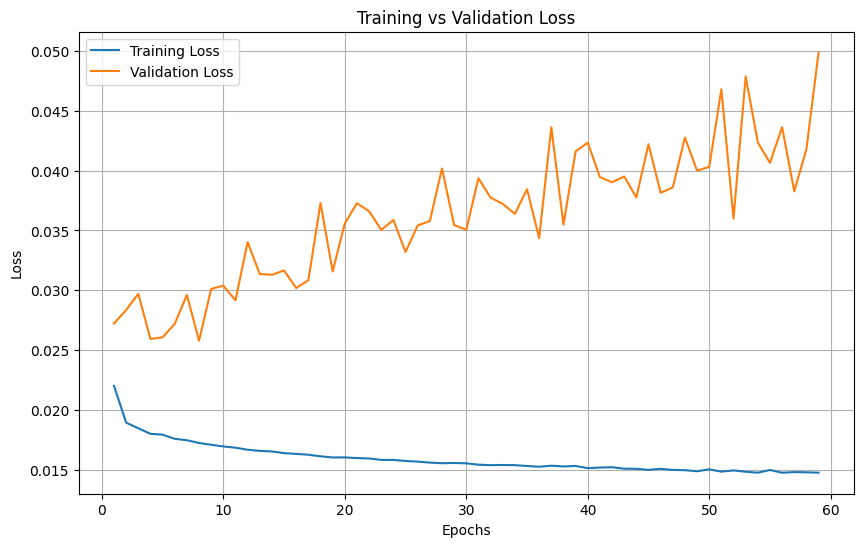

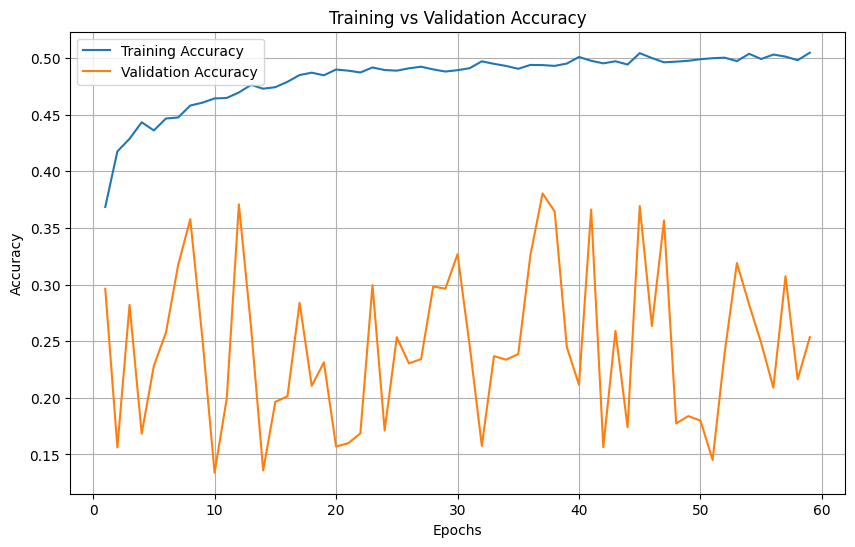

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input,

Test Loss: 0.08839


/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input,

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# Sample configuration class to store hyperparameters
class Config:
    def __init__(self):
        self.batch_size = 60
        self.seq_len = 100  # Length of each sequence for input to the CNN
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.epoch = 80
        self.lr = 5e-4
        self.weight_decay = 2e-4
        self.save_model = 'SOC_Model'

# Step 1: Define a custom Dataset class
sc=None

class SOCDataset(Dataset):
    def __init__(self, data, seq_len):
        """
        Initializes the dataset with sequences.
        Args:
            data (pd.DataFrame): The DataFrame containing the time-series data.
            seq_len (int): The length of each sequence for input to the CNN.
        """
      # Convert timestamp to numeric format (e.g., Unix timestamp)
 # Specify the format explicitly
        data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
        # errors='coerce' will set invalid parsing to NaT, which you can then drop if needed

        data['timestamp'] = data['timestamp'].astype('int64') / 1e9  # Convert to seconds
        numericals = ['timestamp', 'voltage', 'current', 'soc']

        global sc
        if sc==None:
          sc = MinMaxScaler()
          data[numericals] = sc.fit_transform(data[numericals])
        else:
          data[numericals] = sc.transform(data[numericals])
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # Extract a sequence of data for input features (timestamp, voltage, current)
        x = self.data.iloc[idx: idx + self.seq_len][['timestamp', 'voltage', 'current']].values
        x = x.astype(np.float32)  # Convert to float32

        y = self.data.iloc[idx + self.seq_len]['soc']  # Target SOC at the end of sequence
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
# Step 2: Load data from CSV file and preprocess
data = pd.read_csv('/kaggle/input/dataset/Data.csv')  # Load data from "Data.csv"
data = data.dropna()

# Step 3: Split into train/validation/test sets (e.g., 70/15/15 split)
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))
train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

# Step 4: Create Dataset and DataLoader for train, validation, and test
config = Config()  # Instantiate the config with parameters
train_dataset = SOCDataset(train_data, config.seq_len)
val_dataset = SOCDataset(val_data, config.seq_len)
test_dataset = SOCDataset(test_data, config.seq_len)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)

# Initialize the CNN model
net = CNN_SOC(config).to(config.device)

# Train the model with train and validation loaders
train_losses, val_losses, train_accuracies, val_accuracies = net.train_model(train_loader, val_loader)  # Pass val_loader for validation

# Testing loop
net.eval()  # Set model to evaluation mode
test_loss = 0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)
        pred = net.predict(x_batch)
        loss = net.mse(pred, y_batch)
        test_loss += loss.item()

print(f"Test Loss: {test_loss / len(test_loader):.5f}")


In [19]:
def calculate_metrics(data_loader, model, config, criterion, is_train=True):
    """
    Calculates accuracy and loss for a given data loader.

    Args:
        data_loader (DataLoader): Data loader for train, validation, or test data.
        model (nn.Module): The model to evaluate.
        config (Config): Configuration object containing hyperparameters and device info.
        criterion (nn.Module): Loss function to use for loss calculation.
        is_train (bool): Whether the mode is training. Defaults to True.

    Returns:
        Tuple[float, float]: Accuracy (percentage) and average loss.
    """
    if is_train:
        model.train()  # Set model to training mode
    else:
        model.eval()  # Set model to evaluation mode

    total_correct = 0
    total_samples = 0
    total_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)
            outputs = model.predict(x_batch).squeeze()

            # Compute loss
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)  # Sum up losses weighted by batch size

            # Calculate accuracy
            predictions = outputs.cpu().numpy().flatten()
            targets = y_batch.cpu().numpy().flatten()

            # Accuracy within a tolerance range (e.g., 5%)
            tolerance = 0.05  # Adjust tolerance as needed
            correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
            total_correct += correct_predictions
            total_samples += len(targets)

    accuracy = total_correct / total_samples * 100  # Percentage accuracy
    avg_loss = total_loss / total_samples * 100  # Average loss
    return accuracy, avg_loss
# Define the loss function
criterion = torch.nn.MSELoss()

# Calculate training accuracy and loss
train_accuracy, train_loss = calculate_metrics(train_loader, net, config, criterion, is_train=True)
print(f'Training Accuracy: {train_accuracy:.2f}%, Training Loss: {train_loss:.2f}%')

# Calculate validation accuracy and loss
val_accuracy, val_loss = calculate_metrics(val_loader, net, config, criterion, is_train=False)
print(f'Validation Accuracy: {val_accuracy:.2f}%, Validation Loss: {val_loss:.2f}%')

# Calculate test accuracy and loss
test_accuracy, test_loss = calculate_metrics(test_loader, net, config, criterion, is_train=False)
print(f'Test Accuracy: {test_accuracy:.2f}%, Test Loss: {test_loss:.2f}%')


/tmp/ipykernel_30/699954045.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/699954045.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/699954045.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/699954045.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)


Training Accuracy: 54.08%, Training Loss: 1.45%
Validation Accuracy: 30.61%, Validation Loss: 4.78%
Test Accuracy: 31.50%, Test Loss: 8.60%


In [102]:
import torch
import torch.nn as nn
import os

class LSTM_SOC(nn.Module):
    def __init__(self, config):
        super(LSTM_SOC, self).__init__()
        self.device = config.device
        self.config = config


        # Define the LSTM and output layers
        self.lstm = nn.LSTM(
            input_size=3,  # Expecting 3 features (e.g., voltage, current, SOC)
            hidden_size=32,
            num_layers=2,
            batch_first=True
        )
        self.fc = nn.Linear(32, 1)  # Map the hidden state to a single SOC value

        # Model saving logic
        if config.save_model is not None:
            save_dir = 'results'
            if not os.path.exists(save_dir):
                os.makedirs(save_dir)
            self.save_name = f'results/LSTM_SOC-{config.save_model}-batch_size={config.batch_size}-seq_len={config.seq_len}.pkl'
        else:
            self.save_name = None

        # Optimizer and scheduler
        self.optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.MultiStepLR(self.optimizer, [100, 500], gamma=0.5)

        # Loss function
        self.mse = nn.MSELoss()
        self.iter = 0

    def predict(self, input_seq):
        """
        Predict SOC for the given input sequence.

        Args:
            input_seq: Tensor of shape [batch_size, seq_len, features].
        Returns:
            predictions: Tensor of shape [batch_size, seq_len].
        """
        input_seq = input_seq.to(self.device)  # Ensure data is on the correct device
        output, (h, c) = self.lstm(input_seq)  # [batch_size, seq_len, hidden_size]
        predictions = self.fc(output[:, -1, :])  # Use the last LSTM output
        return predictions

    def train_one_epoch(self, x_batch, y_batch, print_per):
        self.optimizer.zero_grad()

        # Forward pass
        pred = self.predict(x_batch)  # [batch_size, seq_len]
        pred = pred[:, -1]  # Use the last timestep prediction for SOC

        y_batch = y_batch.to(self.device)  # [batch_size]
        l_mse = self.mse(pred, y_batch)

        # Backward pass and optimization
        loss = l_mse
        loss.backward()
        self.optimizer.step()
        self.iter += 1

        # Print loss
        lr = self.optimizer.state_dict()['param_groups'][0]['lr']
        print(f"\r{self.iter} loss: {loss.item():.5e}  l_mse: {l_mse.item():.7f}, lr: {lr:.4f}", end='')
        if self.iter % print_per == 0:
            print("")
        return loss

    def train_model(self, train_loader,val_loader, print_per=50):
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        min_loss = float('inf')
        stop = 0

        for e in range(self.config.epoch):
            self.train()
            epoch_train_loss = 0
            total_correct_train = 0
            total_samples_train = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                loss = self.train_one_epoch(x_batch, y_batch, print_per)
                epoch_train_loss += loss.item()

                with torch.no_grad():
                      pred = self.predict(x_batch)
                      correct_predictions = torch.abs(pred - y_batch.view(-1, 1)) / y_batch.view(-1, 1) <= 0.05
                      total_correct_train += correct_predictions.sum().item()
                      total_samples_train += y_batch.size(0)

            avg_train_loss=epoch_train_loss/len(train_loader)
            train_losses.append(avg_train_loss)
            train_accuracies.append((total_correct_train / total_samples_train))


            # Validation phase
            self.eval()
            epoch_val_loss = 0
            total_correct_val = 0
            total_samples_val = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                    pred = self.predict(x_batch)
                    y_batch = y_batch.view(-1, 1)
                    val_loss = self.mse(pred, y_batch)
                    epoch_val_loss += val_loss.item()

                    correct_predictions = torch.abs(pred - y_batch) / y_batch <= 0.05
                    total_correct_val += correct_predictions.sum().item()
                    total_samples_val += y_batch.size(0)

            avg_val_loss = epoch_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            val_accuracies.append((total_correct_val / total_samples_val))
        
            print(f"\nEpoch [{e+1}/{self.config.epoch}], "
              f"Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}, "
              f"Train Accuracy: {train_accuracies[-1]:.5f}, Val Accuracy: {val_accuracies[-1]:.5f}")

            self.scheduler.step()
            stop += 1
            if avg_val_loss < min_loss:
                min_loss = avg_val_loss
                stop = 0
                self.best_state = {
                    'net': self.state_dict(),
                    'optimizer': self.optimizer.state_dict(),
                    'epoch': self.iter
                }
            if stop > 50:
                print('\nEarly stopping triggered.')
                break
                        
        self.save_model()
        
  # Plot training and validation losses
        self.plot_losses(train_losses, val_losses)
        self.plot_accuracies(train_accuracies, val_accuracies)

        return train_losses, val_losses, train_accuracies, val_accuracies
        
    def plot_losses(self, train_losses, val_losses):
        """
        Plot training and validation losses.
        Args:
        train_losses: List of training losses.
        val_losses: List of validation losses.
        """
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
        plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_accuracies(self, train_accuracies, val_accuracies):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Training Accuracy")
        plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Validation Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title("Training vs Validation Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    def save_model(self):
        if self.save_name is not None:
            torch.save(self.best_state, self.save_name)

    def load_model(self):
        if self.save_name is not None:
            checkpoint = torch.load(self.save_name)
            self.load_state_dict(checkpoint['net'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            self.iter = checkpoint['epoch'] + 1



/tmp/ipykernel_30/3265210463.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
/tmp/ipykernel_30/3265210463.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['timestamp'] = data['timestamp'].astype('int64') / 1e9  # Convert to seconds
/tmp/ipykernel_30/3265210463.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

50 loss: 5.60481e-01  l_mse: 0.5604814, lr: 0.0001
100 loss: 4.33971e-01  l_mse: 0.4339707, lr: 0.0001
150 loss: 1.55564e-01  l_mse: 0.1555640, lr: 0.0001
200 loss: 4.42086e-02  l_mse: 0.0442086, lr: 0.0001
250 loss: 2.19714e-02  l_mse: 0.0219714, lr: 0.0001
300 loss: 2.62804e-02  l_mse: 0.0262804, lr: 0.0001
350 loss: 1.62851e-02  l_mse: 0.0162851, lr: 0.0001
400 loss: 1.96511e-02  l_mse: 0.0196511, lr: 0.0001
450 loss: 1.08397e-02  l_mse: 0.0108397, lr: 0.0001
500 loss: 6.39916e-03  l_mse: 0.0063992, lr: 0.0001
550 loss: 2.67342e-03  l_mse: 0.0026734, lr: 0.0001
600 loss: 4.49658e-03  l_mse: 0.0044966, lr: 0.0001
650 loss: 6.86218e-03  l_mse: 0.0068622, lr: 0.0001
700 loss: 5.08784e-03  l_mse: 0.0050878, lr: 0.0001
750 loss: 8.20178e-04  l_mse: 0.0008202, lr: 0.0001
800 loss: 1.84328e-03  l_mse: 0.0018433, lr: 0.0001
850 loss: 2.13109e-03  l_mse: 0.0021311, lr: 0.0001
900 loss: 1.55085e-03  l_mse: 0.0015509, lr: 0.0001
944 loss: 1.10927e-03  l_mse: 0.0011093, lr: 0.0001
Epoch [1/100]

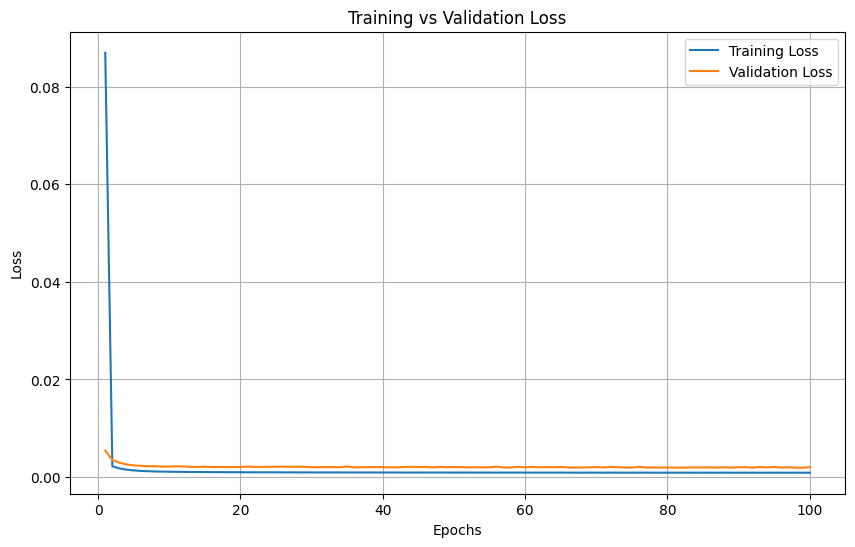

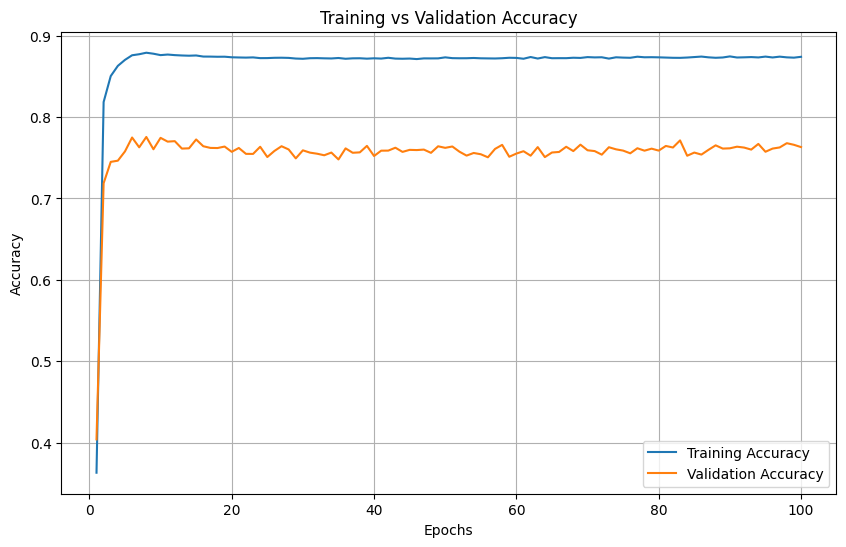

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input,

Test Loss: 0.00467


/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input,

In [103]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Sample configuration class to store hyperparameters
class Config:
    def __init__(self):
        self.batch_size = 60
        self.seq_len = 100  # Length of each sequence for input to the CNN
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.epoch = 100
        self.lr = 1e-4
        self.weight_decay = 2e-4
        self.save_model = 'SOC_Model.pkl'  # Model save filename
        self.save_scaler = 'scaler.pkl'    # Scaler save filename

# Step 1: Define a custom Dataset class
sc = None

class SOCDataset(Dataset):
    def __init__(self, data, seq_len):
        """
        Initializes the dataset with sequences.
        Args:
            data (pd.DataFrame): The DataFrame containing the time-series data.
            seq_len (int): The length of each sequence for input to the CNN.
        """
        # Convert timestamp to numeric format (e.g., Unix timestamp)
        data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
        data['timestamp'] = data['timestamp'].astype('int64') / 1e9  # Convert to seconds
        numericals = ['timestamp', 'voltage', 'current', 'soc']

        global sc
        if sc is None:
            sc = MinMaxScaler()
            data[numericals] = sc.fit_transform(data[numericals])
        else:
            data[numericals] = sc.transform(data[numericals])

        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # Extract a sequence of data for input features (timestamp, voltage, current)
        x = self.data.iloc[idx: idx + self.seq_len][['timestamp', 'voltage', 'current']].values
        x = x.astype(np.float32)  # Convert to float32
        y = self.data.iloc[idx + self.seq_len]['soc']  # Target SOC at the end of sequence
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Step 2: Load data from CSV file and preprocess
data = pd.read_csv('/kaggle/input/dataset/Data.csv')  # Load data from "Data.csv"
data = data.dropna()

# Step 3: Split into train/validation/test sets (e.g., 70/15/15 split)
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))
train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

# Step 4: Create Dataset and DataLoader for train, validation, and test
config = Config()  # Instantiate the config with parameters
train_dataset = SOCDataset(train_data, config.seq_len)
val_dataset = SOCDataset(val_data, config.seq_len)
test_dataset = SOCDataset(test_data, config.seq_len)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)



# Initialize the LSTM model
lstm_net = LSTM_SOC(config).to(config.device)

# Step 5: Training loop
train_losses, val_losses, train_accuracies, val_accuracies = lstm_net.train_model(train_loader, val_loader)  # Trains the model using the train loader

# Step 7: Testing/Validation loop
lstm_net.eval()  # Set model to evaluation mode
test_loss = 0
with torch.no_grad():  # Disable gradient computation for testing
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)
        pred = lstm_net.predict(x_batch)
      #  pred = pred[:, -1]  # Use the last timestep's prediction
        loss = lstm_net.mse(pred, y_batch)
        test_loss += loss.item()

print(f"Test Loss: {test_loss / len(test_loader):.5f}")



In [108]:
def calculate_metrics(data_loader, model, config, criterion, is_train=True):
    """
    Calculates accuracy and loss for a given data loader.

    Args:
        data_loader (DataLoader): Data loader for train, validation, or test data.
        model (nn.Module): The model to evaluate.
        config (Config): Configuration object containing hyperparameters and device info.
        criterion (nn.Module): Loss function to use for loss calculation.
        is_train (bool): Whether the mode is training. Defaults to True.

    Returns:
        Tuple[float, float]: Accuracy (percentage) and average loss.
    """
    if is_train:
        model.train()  # Set model to training mode
    else:
        model.eval()  # Set model to evaluation mode

    total_correct = 0
    total_samples = 0
    total_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)
            outputs = model.predict(x_batch).squeeze()

            # Compute loss
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)  # Sum up losses weighted by batch size

            # Calculate accuracy
            predictions = outputs.cpu().numpy().flatten()
            targets = y_batch.cpu().numpy().flatten()

            # Accuracy within a tolerance range (e.g., 5%)
            tolerance = 0.05  # Adjust tolerance as needed
            correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
            total_correct += correct_predictions
            total_samples += len(targets)

    accuracy = total_correct / total_samples * 100  # Percentage accuracy
    avg_loss = total_loss / total_samples * 100  # Average loss
    return accuracy, avg_loss
# Define the loss function
criterion = torch.nn.MSELoss()

# Calculate training accuracy and loss
train_accuracy, train_loss = calculate_metrics(train_loader, lstm_net, config, criterion, is_train=True)
print(f'Training Accuracy: {train_accuracy:.2f}%, Training Loss: {train_loss:.2f}%')

# Calculate validation accuracy and loss
val_accuracy, val_loss = calculate_metrics(val_loader, lstm_net, config, criterion, is_train=False)
print(f'Validation Accuracy: {val_accuracy:.2f}%, Validation Loss: {val_loss:.2f}%')

# Calculate test accuracy and loss
test_accuracy, test_loss = calculate_metrics(test_loader, lstm_net, config, criterion, is_train=False)
print(f'Test Accuracy: {test_accuracy:.2f}%, Test Loss: {test_loss:.2f}%')


/tmp/ipykernel_30/3091970662.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/3091970662.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/3091970662.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/3091970662.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)


Training Accuracy: 87.57%, Training Loss: 0.09%
Validation Accuracy: 76.31%, Validation Loss: 0.20%
Test Accuracy: 74.98%, Test Loss: 0.11%


In [123]:
import torch
import torch.nn as nn
import os

class CNN_LSTM(nn.Module):
    def __init__(self, config):
        super(CNN_LSTM, self).__init__()
        self.device = config.device
        self.config = config

         # Define the CNN layers
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

        # Define the LSTM layers
        self.lstm = nn.LSTM(
            input_size=64,  # Match CNN's output size as input to LSTM
            hidden_size=32,  # Hidden size of LSTM
            num_layers=2,    # Number of LSTM layers
            batch_first=True
        )

        # Fully connected layer for final prediction
        self.fc = nn.Linear(32, 1)  # Map the last LSTM output to SOC value

        # Model saving logic
        if config.save_model is not None:
            save_dir = 'results'
            if not os.path.exists(save_dir):
                os.makedirs(save_dir)
            self.save_name = f'results/CNN_LSTM-{config.save_model}-batch_size={config.batch_size}-seq_len={config.seq_len}.pkl'
        else:
            self.save_name = None

        # Optimizer and scheduler
        self.optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay
        )
        self.scheduler = torch.optim.lr_scheduler.MultiStepLR(self.optimizer, [100, 500], gamma=0.5)

        # Loss function
        self.mse = nn.MSELoss()
        self.iter = 0

    def predict(self, input_seq):
        """
        Predict SOC for the given input sequence.

        Args:
            input_seq: Tensor of shape [batch_size, seq_len, features].
        Returns:
            predictions: Tensor of shape [batch_size, seq_len].
        """
        input_seq = input_seq.permute(0, 2, 1)  # [batch_size, features, seq_len]
        cnn_out = self.cnn(input_seq)          # [batch_size, 128, seq_len]
        cnn_out = cnn_out.permute(0, 2, 1)     # [batch_size, seq_len, 128]
        
        lstm_out, _ = self.lstm(cnn_out)       # [batch_size, seq_len, hidden_size]
        predictions = self.fc(lstm_out[:, -1, :])  # Use the last LSTM output
        return predictions        # [batch_size]

    def train_one_epoch(self, x_batch, y_batch, print_per):
        self.optimizer.zero_grad()

        # Forward pass
        pred = self.predict(x_batch)  # [batch_size]
        pred= pred[:,-1]
        # Compute loss
        y_batch = y_batch.to(self.device)  # [batch_size]
        l_mse = self.mse(pred, y_batch)

        # Backward pass and optimization
        loss = l_mse
        loss.backward()
        self.optimizer.step()
        self.iter += 1

        # Print loss
        lr = self.optimizer.state_dict()['param_groups'][0]['lr']
        print(f"\r{self.iter} loss: {loss.item():.5e}  l_mse: {l_mse.item():.7f}, lr: {lr:.4f}", end='')
        if self.iter % print_per == 0:
            print("")
        return loss

    def train_model(self, train_loader,val_loader, print_per=50):
        train_losses = []
        val_losses = []
        train_accuracies = []
        val_accuracies = []
        min_loss = float('inf')
        stop = 0

        for e in range(self.config.epoch):
            self.train()
            epoch_train_loss = 0
            total_correct_train = 0
            total_samples_train = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                loss = self.train_one_epoch(x_batch, y_batch, print_per)
                epoch_train_loss += loss.item()

                with torch.no_grad():
                      pred = self.predict(x_batch)
                      correct_predictions = torch.abs(pred - y_batch.view(-1, 1)) / y_batch.view(-1, 1) <= 0.05
                      total_correct_train += correct_predictions.sum().item()
                      total_samples_train += y_batch.size(0)

            avg_train_loss=epoch_train_loss/len(train_loader)
            train_losses.append(avg_train_loss)
            train_accuracies.append((total_correct_train / total_samples_train))


            # Validation phase
            self.eval()
            epoch_val_loss = 0
            total_correct_val = 0
            total_samples_val = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                    pred = self.predict(x_batch)
                    y_batch = y_batch.view(-1, 1)
                    val_loss = self.mse(pred, y_batch)
                    epoch_val_loss += val_loss.item()

                    correct_predictions = torch.abs(pred - y_batch) / y_batch <= 0.05
                    total_correct_val += correct_predictions.sum().item()
                    total_samples_val += y_batch.size(0)

            avg_val_loss = epoch_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            val_accuracies.append((total_correct_val / total_samples_val))
        
            print(f"\nEpoch [{e+1}/{self.config.epoch}], "
              f"Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}, "
              f"Train Accuracy: {train_accuracies[-1]:.2f}, Val Accuracy: {val_accuracies[-1]:.2f}")

            # avg_epoch_loss = epoch_loss / len(train_loader)
            # print(f"\nEpoch [{e+1}/{self.config.epoch}], Loss: {avg_epoch_loss:.10f}")
            self.scheduler.step()
            stop += 1
            if avg_val_loss < min_loss:
                min_loss = avg_val_loss
                stop = 0
                self.best_state = {
                    'net': self.state_dict(),
                    'optimizer': self.optimizer.state_dict(),
                    'epoch': self.iter
                }
            if stop > 50:
                print('\nEarly stopping triggered.')
                break
                        
        self.save_model()
        
    # Plot training and validation losses
        self.plot_losses(train_losses, val_losses)
        self.plot_accuracies(train_accuracies, val_accuracies)

        return train_losses, val_losses, train_accuracies, val_accuracies
        
    def plot_losses(self, train_losses, val_losses):
        """
        Plot training and validation losses.
        Args:
        train_losses: List of training losses.
        val_losses: List of validation losses.
        """
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
        plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training vs Validation Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    def plot_accuracies(self, train_accuracies, val_accuracies):
        
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label="Training Accuracy")
        plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label="Validation Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.title("Training vs Validation Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    def save_model(self):
        if self.save_name is not None:
            torch.save(self.best_state, self.save_name)

    def load_model(self):
        if self.save_name is not None:
            checkpoint = torch.load(self.save_name)
            self.load_state_dict(checkpoint['net'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            self.iter = checkpoint['epoch'] + 1


/tmp/ipykernel_30/1039686029.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
/tmp/ipykernel_30/1039686029.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['timestamp'] = data['timestamp'].astype('int64') / 1e9  # Convert to seconds
/tmp/ipykernel_30/1039686029.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

50 loss: 5.55938e-02  l_mse: 0.0555938, lr: 0.0005
100 loss: 8.32024e-03  l_mse: 0.0083202, lr: 0.0005
150 loss: 6.03680e-04  l_mse: 0.0006037, lr: 0.0005
200 loss: 7.20132e-04  l_mse: 0.0007201, lr: 0.0005
250 loss: 5.04639e-04  l_mse: 0.0005046, lr: 0.0005
300 loss: 4.28926e-04  l_mse: 0.0004289, lr: 0.0005
350 loss: 3.65495e-04  l_mse: 0.0003655, lr: 0.0005
400 loss: 1.06961e-03  l_mse: 0.0010696, lr: 0.0005
450 loss: 9.18899e-04  l_mse: 0.0009189, lr: 0.0005
500 loss: 2.54465e-04  l_mse: 0.0002545, lr: 0.0005
550 loss: 1.13670e-03  l_mse: 0.0011367, lr: 0.0005
600 loss: 1.37964e-03  l_mse: 0.0013796, lr: 0.0005
650 loss: 4.84029e-04  l_mse: 0.0004840, lr: 0.0005
700 loss: 3.39940e-04  l_mse: 0.0003399, lr: 0.0005
750 loss: 1.59430e-03  l_mse: 0.0015943, lr: 0.0005
800 loss: 4.25221e-04  l_mse: 0.0004252, lr: 0.0005
850 loss: 6.12397e-04  l_mse: 0.0006124, lr: 0.0005
900 loss: 2.91172e-04  l_mse: 0.0002912, lr: 0.0005
944 loss: 5.47636e-04  l_mse: 0.0005476, lr: 0.0005
Epoch [1/100]

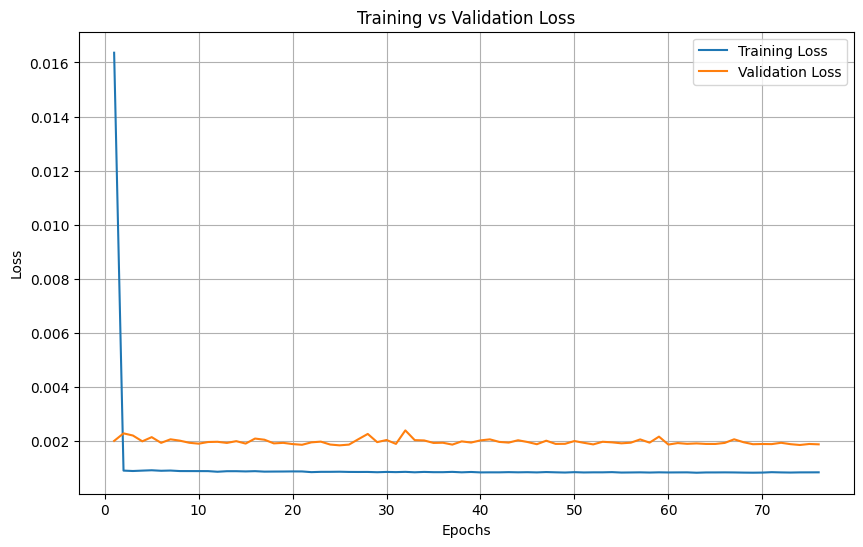

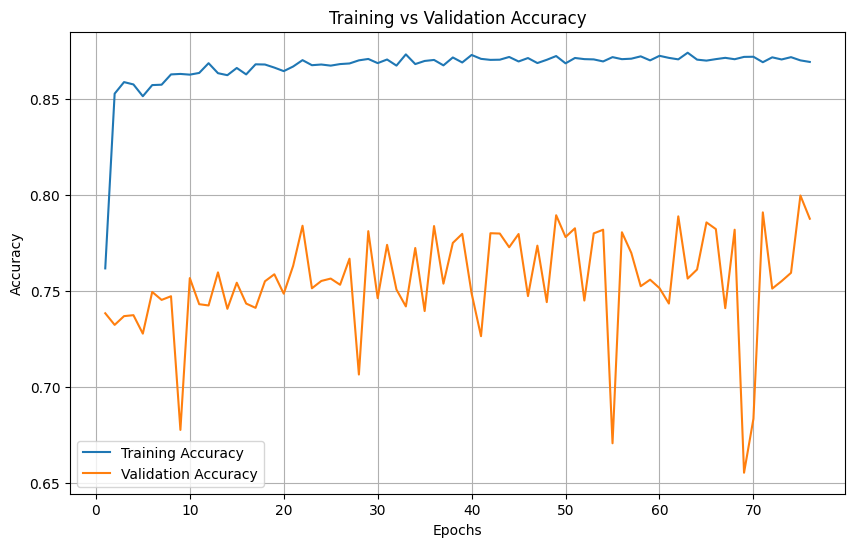

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input,

Test Loss: 0.00482


/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/conda/lib/python3.10/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([60])) that is different to the input size (torch.Size([60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input,

In [124]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Sample configuration class to store hyperparameters
class Config:
    def __init__(self):
        self.batch_size = 60
        self.seq_len = 100  # Length of each sequence for input to the CNN-LSTM
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.epoch = 100
        self.lr = 5e-4
        self.weight_decay = 2e-4
        self.save_model = 'CNN_LSTM_Model.pkl'  # Model save filename
        self.save_scaler = 'scaler.pkl'        # Scaler save filename

# Step 1: Define a custom Dataset class
sc = None

class SOCDataset(Dataset):
    def __init__(self, data, seq_len):
        """
        Initializes the dataset with sequences.
        Args:
            data (pd.DataFrame): The DataFrame containing the time-series data.
            seq_len (int): The length of each sequence for input to the CNN-LSTM.
        """
        # Convert timestamp to numeric format (e.g., Unix timestamp)
        data['timestamp'] = pd.to_datetime(data['timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
        data['timestamp'] = data['timestamp'].astype('int64') / 1e9  # Convert to seconds
        numericals = ['timestamp', 'voltage', 'current', 'soc']

        global sc
        if sc is None:
            sc = MinMaxScaler()
            data[numericals] = sc.fit_transform(data[numericals])
        else:
            data[numericals] = sc.transform(data[numericals])

        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # Extract a sequence of data for input features (timestamp, voltage, current)
        x = self.data.iloc[idx: idx + self.seq_len][['timestamp', 'voltage', 'current']].values
        x = x.astype(np.float32)  # Convert to float32
        y = self.data.iloc[idx + self.seq_len]['soc']  # Target SOC at the end of sequence
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Step 2: Load data from CSV file and preprocess
data = pd.read_csv('/kaggle/input/dataset/Data.csv')  # Load data from "Data.csv"
data = data.dropna()

# Step 3: Split into train/validation/test sets (e.g., 70/15/15 split)
train_size = int(0.7 * len(data))
val_size = int(0.15 * len(data))
train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

# Step 4: Create Dataset and DataLoader for train, validation, and test
config = Config()  # Instantiate the config with parameters
train_dataset = SOCDataset(train_data, config.seq_len)
val_dataset = SOCDataset(val_data, config.seq_len)
test_dataset = SOCDataset(test_data, config.seq_len)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, drop_last=True)


# Assuming you have already defined a `CNN_LSTM` class with train and predict methods.
cnn_lstm_net = CNN_LSTM(config).to(config.device)

# Step 5: Training loop
train_losses, val_losses, train_accuracies, val_accuracies = cnn_lstm_net.train_model(train_loader, val_loader)  # Trains the model using the train loader


# Step 7: Testing/Validation loop
cnn_lstm_net.eval()  # Set model to evaluation mode
test_loss = 0
with torch.no_grad():  # Disable gradient computation for testing
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)
        pred = cnn_lstm_net.predict(x_batch)
        loss = cnn_lstm_net.mse(pred, y_batch)
        test_loss += loss.item()

print(f"Test Loss: {test_loss / len(test_loader):.5f}")


In [125]:
def calculate_metrics(data_loader, model, config, criterion, is_train=True):
    """
    Calculates accuracy and loss for a given data loader.

    Args:
        data_loader (DataLoader): Data loader for train, validation, or test data.
        model (nn.Module): The model to evaluate.
        config (Config): Configuration object containing hyperparameters and device info.
        criterion (nn.Module): Loss function to use for loss calculation.
        is_train (bool): Whether the mode is training. Defaults to True.

    Returns:
        Tuple[float, float]: Accuracy (percentage) and average loss.
    """
    if is_train:
        model.train()  # Set model to training mode
    else:
        model.eval()  # Set model to evaluation mode

    total_correct = 0
    total_samples = 0
    total_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(config.device), y_batch.to(config.device)
            outputs = model.predict(x_batch).squeeze()

            # Compute loss
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * y_batch.size(0)  # Sum up losses weighted by batch size

            # Calculate accuracy
            predictions = outputs.cpu().numpy().flatten()
            targets = y_batch.cpu().numpy().flatten()

            # Accuracy within a tolerance range (e.g., 5%)
            tolerance = 0.05  # Adjust tolerance as needed
            correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
            total_correct += correct_predictions
            total_samples += len(targets)

    accuracy = total_correct / total_samples * 100  # Percentage accuracy
    avg_loss = total_loss / total_samples * 100  # Average loss
    return accuracy, avg_loss
# Define the loss function
criterion = torch.nn.MSELoss()

# Calculate training accuracy and loss
train_accuracy, train_loss = calculate_metrics(train_loader, cnn_lstm_net, config, criterion, is_train=True)
print(f'Training Accuracy: {train_accuracy:.2f}%, Training Loss: {train_loss:.2f}%')

# Calculate validation accuracy and loss
val_accuracy, val_loss = calculate_metrics(val_loader, cnn_lstm_net, config, criterion, is_train=False)
print(f'Validation Accuracy: {val_accuracy:.2f}%, Validation Loss: {val_loss:.2f}%')

# Calculate test accuracy and loss
test_accuracy, test_loss = calculate_metrics(test_loader, cnn_lstm_net, config, criterion, is_train=False)
print(f'Test Accuracy: {test_accuracy:.2f}%, Test Loss: {test_loss:.2f}%')


/tmp/ipykernel_30/4250419849.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/4250419849.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/4250419849.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)
/tmp/ipykernel_30/4250419849.py:39: RuntimeWarning: divide by zero encountered in divide
  correct_predictions = np.sum(np.abs(predictions - targets) / targets <= tolerance)


Training Accuracy: 88.21%, Training Loss: 0.08%
Validation Accuracy: 78.78%, Validation Loss: 0.19%
Test Accuracy: 82.55%, Test Loss: 0.10%


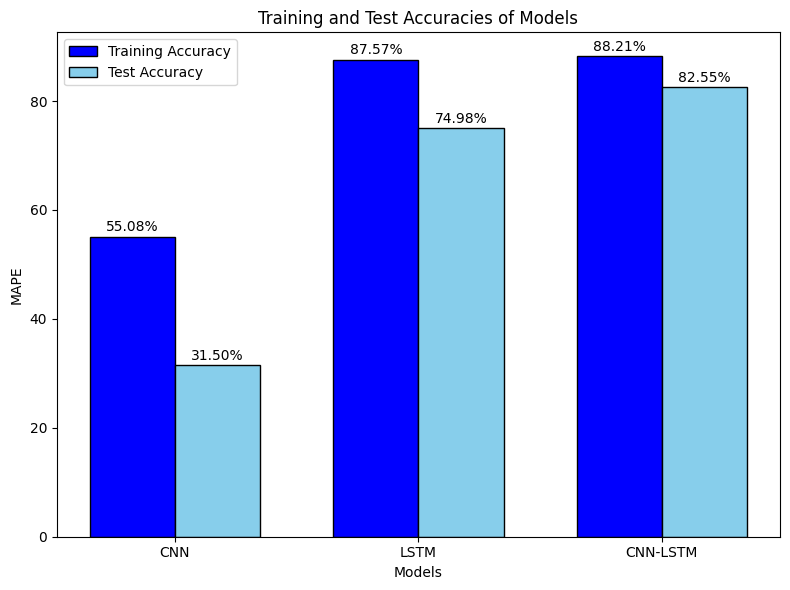

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['CNN', 'LSTM', 'CNN-LSTM']
training_acc = [55.08, 87.57, 88.21]
test_acc = [31.50, 74.98, 82.55]

# X-axis positions for bars
x = np.arange(len(models))

# Bar width
bar_width = 0.35

# Create the histogram
plt.figure(figsize=(8, 6))
plt.bar(x - bar_width / 2, training_acc, width=bar_width, label='Training Accuracy', color='blue', edgecolor='black')
plt.bar(x + bar_width / 2, test_acc, width=bar_width, label='Test Accuracy', color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Training and Test Accuracies of Models', fontsize=12)
plt.xlabel('Models', fontsize=10)
plt.ylabel('MAPE', fontsize=10)
plt.xticks(x, models, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)

# Add accuracy values above bars
for i, (train, test) in enumerate(zip(training_acc, test_acc)):
    plt.text(i - bar_width / 2, train + 1, f'{train:.2f}%', ha='center', fontsize=10)
    plt.text(i + bar_width / 2, test + 1, f'{test:.2f}%', ha='center', fontsize=10)

# Show plot
plt.tight_layout()
plt.show()
